# Day 2 : Northwind SQL Analysis

In [16]:
## Import Libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Connect to Database
conn = sqlite3.connect("northwind.db")

## SQL Analysis

In [3]:
cursor = conn.cursor()

In [4]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


## Query 1: Top 10 Selling Products

In [5]:
query1 = """
SELECT
    p.ProductName,
    SUM(od.Quantity) AS TotalQuantitySold
FROM "Order Details" od
JOIN Products p
ON od.ProductID = p.ProductID
GROUP BY p.ProductID, p.ProductName
ORDER BY TotalQuantitySold DESC
LIMIT 10;
"""

top_products = pd.read_sql(query1, conn)
top_products

,ProductName,TotalQuantitySold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


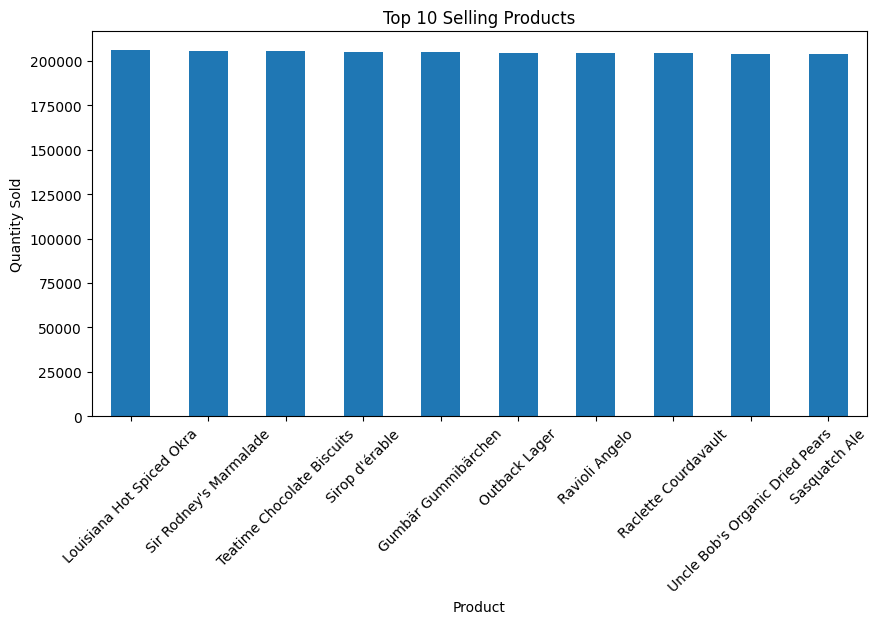

In [6]:
top_products.plot(
    x="ProductName",
    y="TotalQuantitySold",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

### Observation 1

The top-selling products account for a significant share of the total quantity sold. These products are consistently in high demand and should be prioritized for inventory management and promotional campaigns to maximize sales.

## Query 2: Top 10 Customers by Revenue

In [7]:
query2 = """
SELECT
    c.CompanyName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Customers c
JOIN Orders o
ON c.CustomerID = o.CustomerID
JOIN "Order Details" od
ON o.OrderID = od.OrderID
GROUP BY c.CustomerID
ORDER BY Revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query2, conn)
top_customers

,CompanyName,Revenue
0,B's Beverages,6154115.34
1,Hungry Coyote Import Store,5698023.67
2,Rancho grande,5559110.08
3,Gourmet Lanchonetes,5552309.81
4,Ana Trujillo Emparedados y helados,5534356.65
5,Ricardo Adocicados,5524517.31
6,Folies gourmandes,5505502.85
7,Let's Stop N Shop,5462198.02
8,LILA-Supermercado,5437438.34
9,Princesa Isabel Vinhos,5436770.55


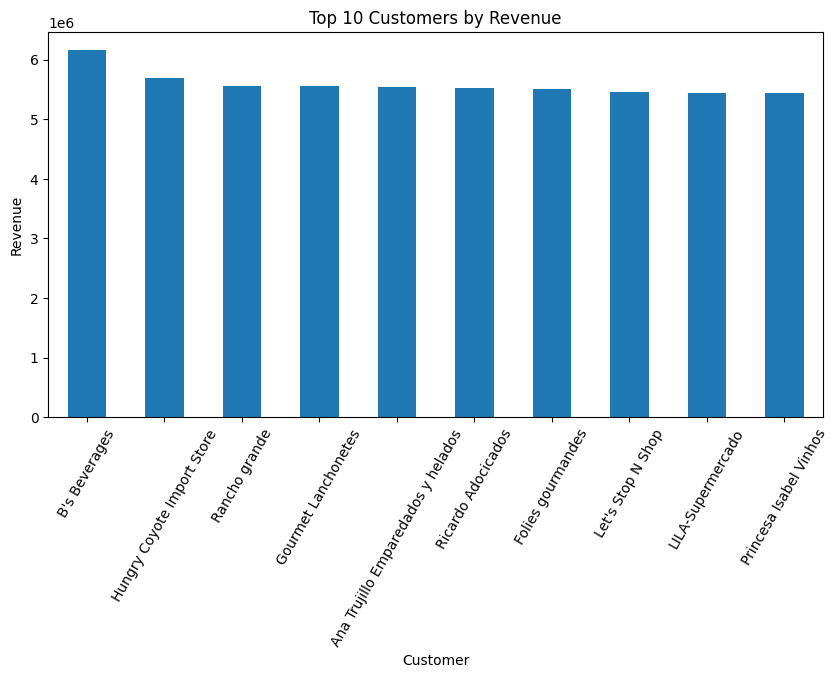

In [8]:
top_customers.plot(
    x="CompanyName",
    y="Revenue",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=60)
plt.show()

### Observation 2

A small group of customers contributes a large portion of the total revenue. Building strong relationships with these high-value customers through loyalty programs and personalized offers can improve customer retention and profitability.

## Query 3: Monthly Sales Trends

In [9]:
query3 = """
SELECT
    strftime('%Y-%m', o.OrderDate) AS Month,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Sales
FROM Orders o
JOIN "Order Details" od
ON o.OrderID = od.OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql(query3, conn)
monthly_sales

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51


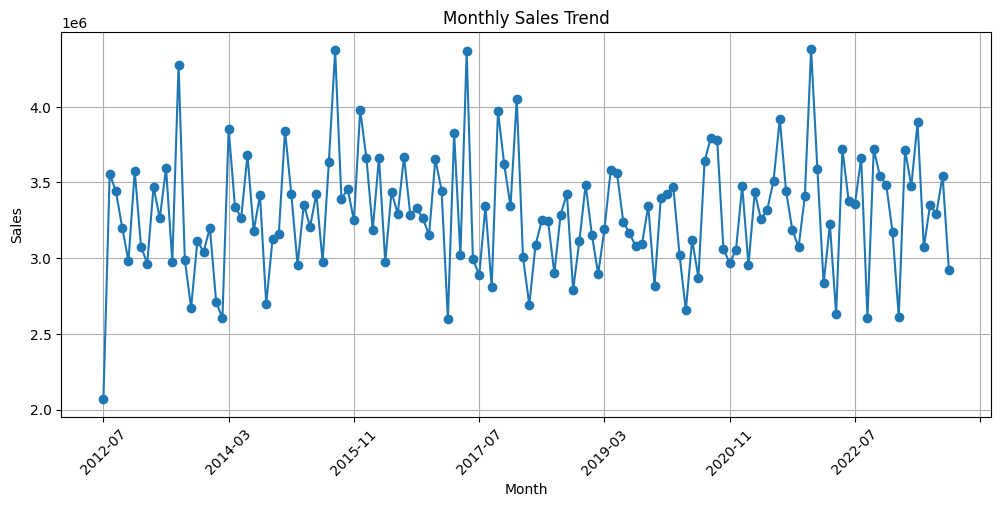

In [10]:
monthly_sales.plot(
    x="Month",
    y="Sales",
    kind="line",
    figsize=(12,5),
    marker="o",
    legend=False
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation 3

Monthly sales show fluctuations throughout the year, indicating seasonal demand patterns. Understanding these trends can help businesses plan inventory, staffing, and marketing campaigns more effectively.

## Query 4: Best-Performing Product Categories

In [11]:
query4 = """
SELECT
    c.CategoryName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Categories c
JOIN Products p
ON c.CategoryID = p.CategoryID
JOIN "Order Details" od
ON p.ProductID = od.ProductID
GROUP BY c.CategoryName
ORDER BY Revenue DESC;
"""

category_sales = pd.read_sql(query4, conn)
category_sales

,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34


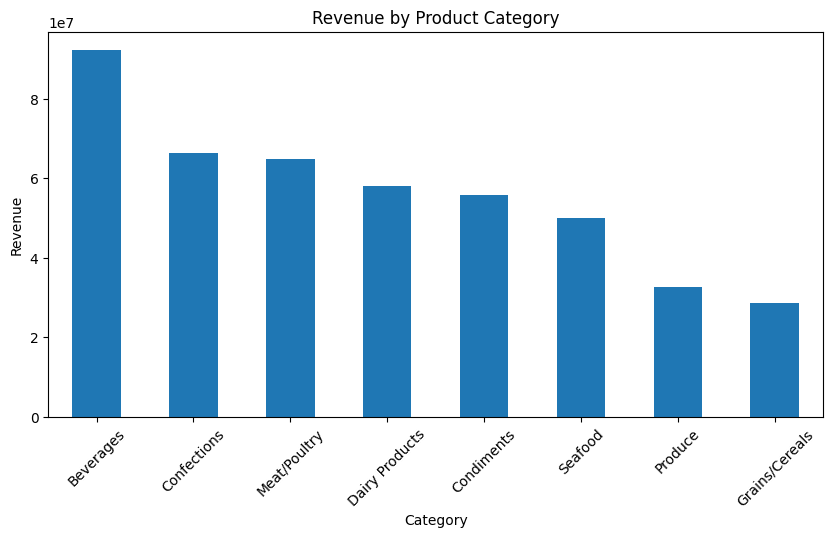

In [12]:
category_sales.plot(
    x="CategoryName",
    y="Revenue",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Observation 4

Some product categories generate significantly higher revenue than others. Focusing on these high-performing categories can improve business growth, while lower-performing categories may require targeted marketing or product optimization.

## Query 5: Customer Purchase Frequency

In [13]:
query5 = """
SELECT
    c.CompanyName,
    COUNT(o.OrderID) AS TotalOrders
FROM Customers c
JOIN Orders o
ON c.CustomerID = o.CustomerID
GROUP BY c.CustomerID
ORDER BY TotalOrders DESC
LIMIT 10;
"""

purchase_frequency = pd.read_sql(query5, conn)
purchase_frequency

,CompanyName,TotalOrders
0,B's Beverages,210
1,Ricardo Adocicados,203
2,LILA-Supermercado,203
3,Gourmet Lanchonetes,202
4,Princesa Isabel Vinhos,200
5,Hungry Coyote Import Store,198
6,Tortuga Restaurante,197
7,Folies gourmandes,195
8,Ana Trujillo Emparedados y helados,195
9,Rancho grande,194


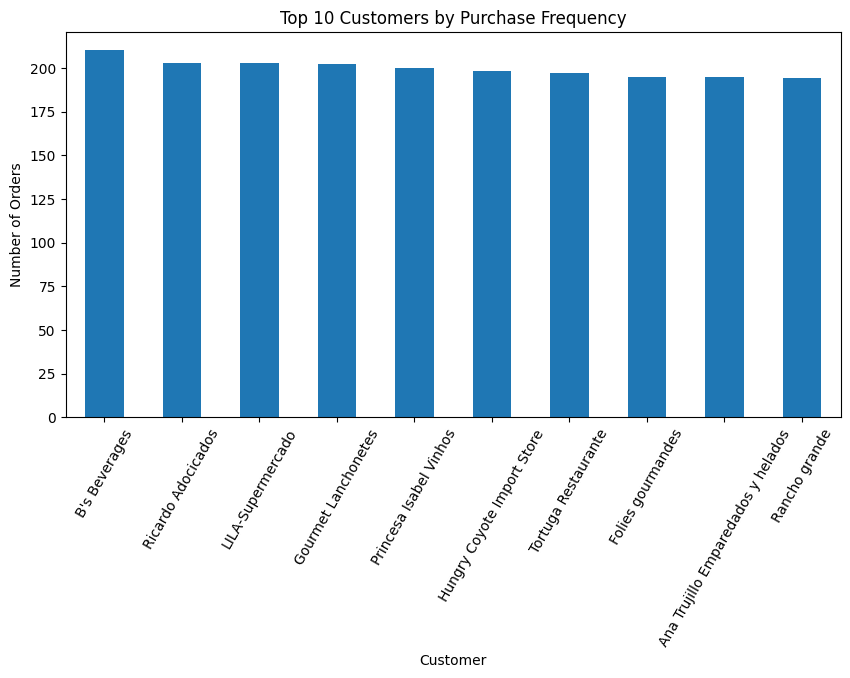

In [14]:
purchase_frequency.plot(
    x="CompanyName",
    y="TotalOrders",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.xticks(rotation=60)
plt.show()

### Observation 5

A few customers place orders much more frequently than the rest. Identifying and rewarding these repeat customers can increase customer loyalty and encourage long-term business relationships.

# Business Insights

1. The top-selling products contribute significantly to overall sales and should be prioritized for inventory management.

2. A small number of customers generate a large share of total revenue, making them valuable for loyalty and retention programs.

3. Monthly sales fluctuate over time, indicating seasonal demand patterns that can guide inventory and marketing decisions.

4. Certain product categories consistently outperform others in revenue, suggesting where the business should focus investment.

5. Repeat customers place orders more frequently than others, highlighting the importance of maintaining long-term customer relationships.